In [1]:
import seaborn as sns
import pandas as pd
import dateparser

from src.config import DATA_DIR

In [2]:
df = pd.read_csv(DATA_DIR / 'reviews.csv', usecols=[1,2,3])

In [3]:
df = df.dropna(how='any')

In [4]:
df['Date'] = df['Date'].apply(lambda x: dateparser.parse(x, languages=['pl']))

In [5]:
df.head()

,Date,Score,Review
0,2026-02-16,2,ich pomoc techniczna to jest jakiś żart
1,2025-06-05,2,"serwis gwarancyjny to jakaś porażka, ile można..."
2,2024-08-08,1,"1 gwiazdka to i tak za dużo, niestety niżej si..."
3,2024-05-08,1,Mam 4 urządzenia od Samsunga i nigdy więcej ni...
5,2017-10-22,1,Całkowicie obużony chce przedstawić moję opini...


In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df.drop_duplicates(inplace=True)

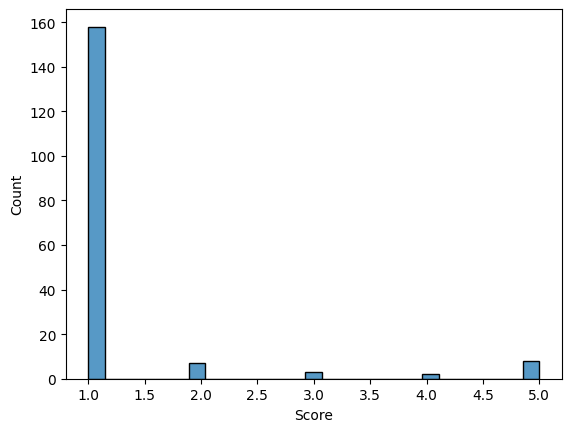

In [8]:
sns.histplot(df['Score'])

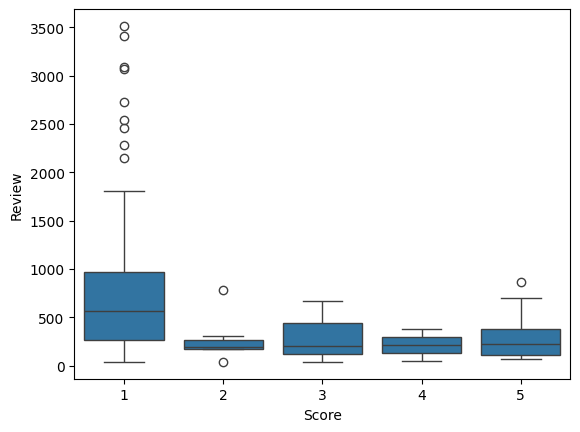

In [9]:
sns.boxplot(x = df['Score'], y = df['Review'].apply(lambda x: len(x)))

In [10]:
years = df.copy()
years['year'] = years['Date'].apply(lambda x: x.year)
years.groupby('year').count()

,Date,Score,Review
year,,,
2017,1,1,1
2024,2,2,2
2025,15,15,15
2026,160,160,160


In [13]:
df.to_csv(DATA_DIR / 'reviews_cleaned.csv', index=False)